In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from scipy.constants import mu_0, epsilon_0
from scipy import fftpack
from scipy import sparse
from scipy.special import factorial
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d, CubicSpline, BSpline
from scipy.sparse import csr_matrix, csc_matrix
import csv
from scipy.special import roots_legendre, eval_legendre
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import lu_factor, lu_solve
from scipy import signal
import ipywidgets
import discretize
import  os
import json
from PIL import Image
import seaborn as sns
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import ipywidgets as widgets
import string
eps = np.finfo(float).eps

In [2]:
import empymod
from masa_utils import PsuedoLog
from masa_utils import Pelton_res_f, DDR_f
from masa_utils import InducedPolarizationSimulation 
from masa_utils import Optimization 
from masa_utils import empymod_IP_simulation
from masa_utils import TEM_Signal_Process


Simulatin and synthetic study on deep sea hydrothermal deposits explortaion using WISTEM (K. Nakayama and A. Saito, 2016) (K.Nakayama M. Motoori and A. Saito,2019). On-Time: 200msec ramp time: 200usec Transmitter Loop: 3.5m Square Loop Receiver Loop: Coincident-type Number of Turn: 5 3.5m rectangular loop has equivalent area for 2.0m circular loop.

In [3]:
# --- helper to render LaTeX labels (robust method) ---
def math_label(tex, width="160px"):
    out = widgets.Output(layout=widgets.Layout(width=width))
    with out:
        display(Math(tex))
    return out
def sci_latex(v, prec=2):
    s = f"{v:.{prec}e}"          # e.g. '3.00e-03'
    mant, exp = s.split('e')
    exp = int(exp)

    if float(mant) == 0:
        return "0"

    if exp in [0, -1]:
        return f"{float(mant)*10**exp:.{prec}f}"
    else:
        return rf"{mant}\cdot 10^{{{exp}}}"


def fmt(v, prec=2, latex=False, wrap=False):
    # blank for None or empty string
    if v is None or v == "":
        return ""

    # if already string → return as-is
    if isinstance(v, str):
        return v

    try:
        s = sci_latex(v, prec=prec)

        if latex:
            if wrap:
                return rf"$${s}$$"   # display math
            else:
                return rf"${s}$"     # inline math
        else:
            return s

    except:
        return ""


In [4]:
plt.style.use('00_figures.mplstyle')
textwidth = 5.60739

In [5]:
rmp_time=200e-6
smp_freq=50e3 #200e3  

In [6]:
tx_side = 3.5
tx_radius = (tx_side)/(np.sqrt(np.pi))
tx_circumeference = 2*np.pi*tx_radius
tx_surface = np.pi*tx_radius**2
n_turns = 5
tx_depth = 0
print(f"Transmitter radius: {tx_radius}")

Transmitter radius: 1.9746635424171473


In [7]:
tstrt, tend = 1e-4, 1e-2
logstep = 1/15
WISTEM_SP_sim = TEM_Signal_Process(
    # base_freq=base_freq,
    # on_time=on_time, 
    rmp_time=rmp_time, 
    rec_time=tend, 
    smp_freq=smp_freq
)


In [8]:
times_sim = WISTEM_SP_sim.times_rec
times_clc = WISTEM_SP_sim.times_rec
ntimes = len(times_clc)
print(ntimes)
print(times_clc[:3], times_clc[-3:])
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
windows_strt = WISTEM_SP_sim.windows_strt
windows_cen = WISTEM_SP_sim.windows_cen
windows_end = WISTEM_SP_sim.windows_end
print(windows_cen-rmp_time)

500
[2.e-05 4.e-05 6.e-05] [0.00996 0.00998 0.01   ]
[0.0001     0.00011659 0.00013594 0.00015849 0.00018478 0.00021544
 0.00025119 0.00029286 0.00034145 0.00039811 0.00046416 0.00054117
 0.00063096 0.00073564 0.0008577  0.001      0.00116591 0.00135936
 0.00158489 0.00184785 0.00215443 0.00251189 0.00292864 0.00341455
 0.00398107 0.00464159 0.0054117  0.00630957 0.00735642 0.00857696]


In [9]:
nlayer =1
nmodel = 4
rho0_targets = 0.1*np.ones(nmodel) # np.r_[0.1 , 0.1 , 0.1 , 0.1]
eta_targets = 0.4*np.ones(nmodel) # np.r_[0.4, 0.4, 0.4 ]
eta_sea , eta_base = 0.,0.
c_targets = 0.7 * np.ones(nmodel) #np.r_[0.7, 0.7, 0.7] 
thick_target = 10.
# tau_targets = np.r_[0.001, 0.01, 0.1]
tau_targets = 0.002 *np.ones(nmodel) ##np.r_[0.01, 0.01, 0.01]

res_sea = 0.3
res_base = 1.0
tau_seas, tau_bases  = tau_targets, tau_targets
c_seas, c_bases,  = c_targets, c_targets
tx_heights = np.r_[0.1, 4 ,10, 15] #csx
# tx_heights = np.r_[13, 14 ,15,16] #csx
depths = []
for tx_height in tx_heights:
    depth = np.r_[0,  thick_target]
    depth += tx_height
    depths.append(depth)
print(f"depths {depths}")

print(tx_heights)

depths [array([ 0.1, 10.1]), array([ 4., 14.]), array([10., 20.]), array([15., 25.])]
[ 0.1  4.  10.  15. ]


In [10]:
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
filt_linrmp = WISTEM_SP_sim.filter_linear_rmp()

Window_mat = WISTEM_SP_sim.get_window_matrix(times_sim)
print(Window_mat.shape)

(30, 500)


In [11]:
recx, recy = 0 , 0
recBdple = [recx, recy, tx_depth ,0,90]
# recx, recy, recw = rec_area(3, tx_side)
# recBdple = [recx, recy, tx_depth ,0,90]

In [12]:

# emoymod model to simulate WISTEM setting
# Note that it simulate only dBdt field at center of the transmitter loop
# User should multiply by area of the loop to get EMF(V/A)

empymod_model_sims = []
for i in range(nmodel):
    depth = depths[i]
    empymod_model_sim = {
        # simulate each bipole of four side of the transmitter loop
        'src': [ tx_side/2, tx_side/2,  # x1,x2
                        0, tx_side/2,  # y1,y2
                tx_depth, tx_depth], # z1,z2
        # receiver at the center of the transmitter loop
        'rec': recBdple, # [recx, recy, tx_depth ,0,90], # dBzdt at x,y,z,azimuth,dip
        'depth': depth,
    #    'res' : res,
        'freqtime': times_sim,
        'signal': None, # 0, # 0: impulse or dBdt, 1: Stepoff or B field
        'msrc' : False, # Electric source
        'mrec' : True, # Magnetic receiver
        'strength': 8.*n_turns* tx_surface * mu_0,  
        'srcpts' : 3,  # Three works for the momtent, maybe worth seeking other number
        'verb': 0, # put 4 for more information
        # Setting xdirect=True can help, as direct field is then computed analytically in f-domain
        'xdirect': True,
    }
    empymod_model_sims.append(empymod_model_sim)

In [13]:

m_trues = []
m_refs = []
sim_obs_cmb = []
for i in range(nmodel):
    rho0_target, eta_target = rho0_targets[i], eta_targets[i]
    tau_target, c_target = tau_targets[i], c_targets[i]
    empymod_model_sim = empymod_model_sims[i]

    m_true  = np.r_[np.log(rho0_target), eta_target, np.log(tau_target), c_target]
    m_trues.append(m_true)


    sim_obs=empymod_IP_simulation(ip_model='pelton',
        model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
        times=times_sim, smp_freq=smp_freq
        )
    sim_obs.deepsea_signle_layer(
        res_sea=res_sea, res_base=res_base,
        eta_sea=eta_sea, eta_base=eta_base,
        tau_sea=tau_target, tau_base=tau_target, 
        c_sea=c_target, c_base=c_target
        )
    sim_obs_cmb.append(sim_obs)



IP model parameters: [-2.30258509  0.4        -6.2146081   0.7       ]
1.39e-03
1.15e+02


[<Axes: xlabel='Frequency (Hz)', ylabel='Amplitude ($\\Omega$m)'>,
 <Axes: xlabel='Frequency (Hz)', ylabel='Phase (deg)'>]

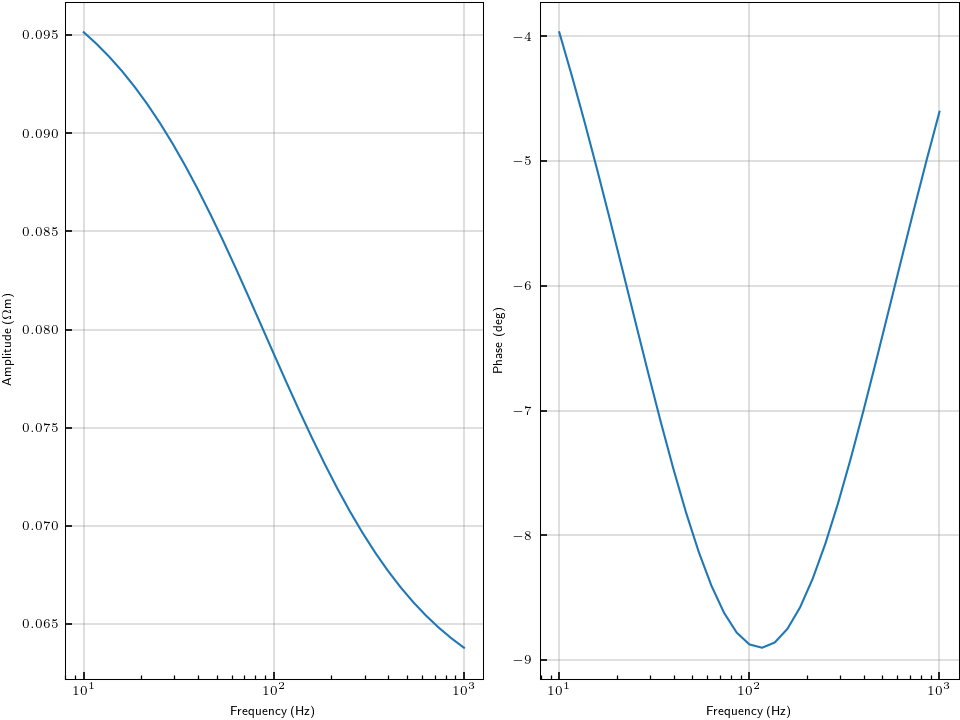

In [14]:
fig, ax = plt.subplots(1,2)
freq = np.logspace(1,3, 31)
ip_model = Pelton_res_f(freq=freq)
sim_sip = InducedPolarizationSimulation(ip_model=ip_model, mode='sip')
ip_model.store_parameters(m_trues[0])
print(f"IP model parameters: {ip_model.p}")
print(f"{ip_model.tau_psi:.2e}")
print(f"{1/2/np.pi/ip_model.tau_psi:.2e}")
sim_sip.plot_sip_model(m_trues[0],ax=ax)

In [15]:
for i in range(nmodel):
    sim_obs = sim_obs_cmb[i]
    print(sim_obs.get_ip_model(m_trues[i]))
    print(sim_obs.model_base['depth'])
    mvec_obs = m_trues[i]
    sim_obs.cut_off = None
    sim_obs.filt_curr = None
    sim_obs.window_mat= None
    dpred_step= sim_obs.dpred(mvec_obs)
    sim_obs.cut_off = smp_freq/2.0
    print(f"cutoff frequency: {sim_obs.cut_off}")
    dpred_LPF = sim_obs.dpred(mvec_obs)
    sim_obs.filt_curr = filt_linrmp
    dpred_rmp = sim_obs.dpred(mvec_obs)
    sim_obs.window_mat=Window_mat
    dpred_window = sim_obs.dpred(mvec_obs)

{'res': array([0.3, 0.1, 1. ]), 'rho_0': array([0.3, 0.1, 1. ]), 'm': array([0. , 0.4, 0. ]), 'tau': array([0.002, 0.002, 0.002]), 'c': array([0.7, 0.7, 0.7]), 'func_eta': <bound method empymod_IP_simulation.pelton_et_al of <masa_utils.empymod_IP_simulation object at 0x0000026D27D12DD0>>}
[ 0.1 10.1]
cutoff frequency: 25000.0
{'res': array([0.3, 0.1, 1. ]), 'rho_0': array([0.3, 0.1, 1. ]), 'm': array([0. , 0.4, 0. ]), 'tau': array([0.002, 0.002, 0.002]), 'c': array([0.7, 0.7, 0.7]), 'func_eta': <bound method empymod_IP_simulation.pelton_et_al of <masa_utils.empymod_IP_simulation object at 0x0000026D2681CF10>>}
[ 4. 14.]
cutoff frequency: 25000.0
{'res': array([0.3, 0.1, 1. ]), 'rho_0': array([0.3, 0.1, 1. ]), 'm': array([0. , 0.4, 0. ]), 'tau': array([0.002, 0.002, 0.002]), 'c': array([0.7, 0.7, 0.7]), 'func_eta': <bound method empymod_IP_simulation.pelton_et_al of <masa_utils.empymod_IP_simulation object at 0x0000026D264F30D0>>}
[10. 20.]
cutoff frequency: 25000.0
{'res': array([0.3, 

In [16]:
m_ref = np.r_[np.log(res_sea), 0, np.log(tau_seas[0]), c_seas[0]]
dpred_ref = sim_obs.dpred(m_ref)

In [17]:
PL_decay = PsuedoLog(
    logmin=1e-8,
    linScale=0.7,
    logminx=1e-4,
    linScalex=0.2
    )
PL_filt = PsuedoLog(
    logmin=1e-7,
    linScale=0.2,
    logminx=1e-4,
    linScalex=0.2
    )
PL_jac = PsuedoLog(
    logmin=1.0,
    linScale=1.0,
    logminx=1e-4,
    linScalex=0.2
    )


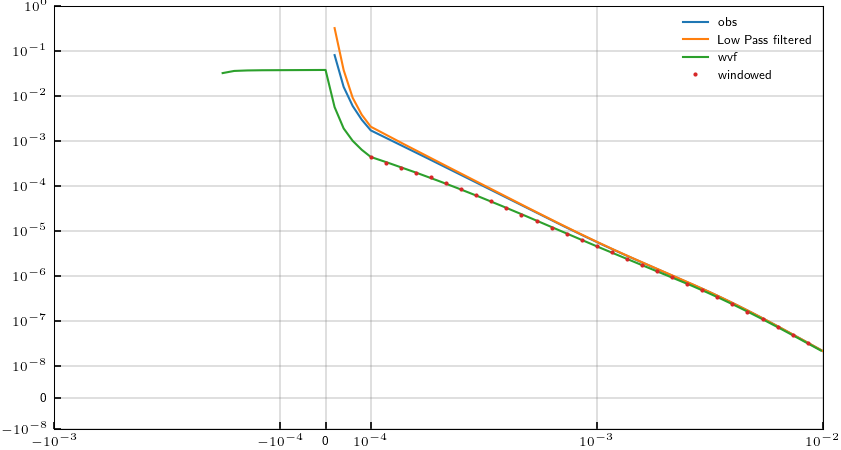

In [18]:
fig, ax= plt.subplots(1,1, figsize=(textwidth,3.0))
ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_step , linestyle="-",label="obs", color="C0",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_LPF , linestyle="-",label="Low Pass filtered", color="C1",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc-rmp_time,y=dpred_rmp , linestyle="-",label="wvf", color="C2",ax=ax)
ax=PL_decay.plpl_plot(
     x= windows_cen-rmp_time,y=dpred_window , marker="o",linestyle="",label="windowed", color="C3",ax=ax)
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)

ax.legend()


In [19]:
relative_error=0.05
data_noise_floor = 0.1e-7

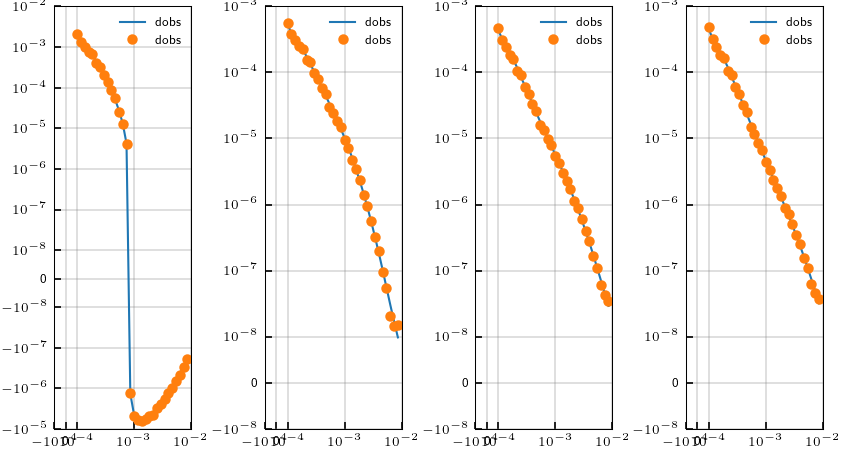

In [20]:
fig, ax= plt.subplots(1,nmodel, figsize=(textwidth,3))
dobs_cmb =[]
ax= ax.flatten()
 # For reproducibility
for i in range(nmodel):
   sim_obs = sim_obs_cmb[i]
   mvec_obs = m_trues[i]
   # np.random.seed(i) # if you wanto have different noise for each model 
    # if you want the same noise for each model
   np.random.seed(1)
   # Calculate noise floor and relative erro at each window
   mvec_obs = m_trues[i]
   dobs_clean=sim_obs.dpred(mvec_obs)
   noise_floor = data_noise_floor
   noise_relative = relative_error * np.abs(dobs_clean)

   # Combine the two sources of noise
   total_noise = np.sqrt(noise_floor**2 + noise_relative**2)

   # Add the combined noise to the clean data
   dobs = dobs_clean +  np.random.randn(len(dobs_clean)) * total_noise

   dobs_cmb.append(dobs)
   ax[i]=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs_clean, 
      label="dobs", color="C0", linestyle="-",ax=ax[i]
   )
   ax[i]=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs, 
      label="dobs", color="C1", marker="o",markersize=4,linestyle="",ax=ax[i]
   )
   ax[i]= PL_decay.pl_axes(ax[i])
   ax[i]= PL_decay.pl_axes_x(ax[i])

   ax[i].legend()
 

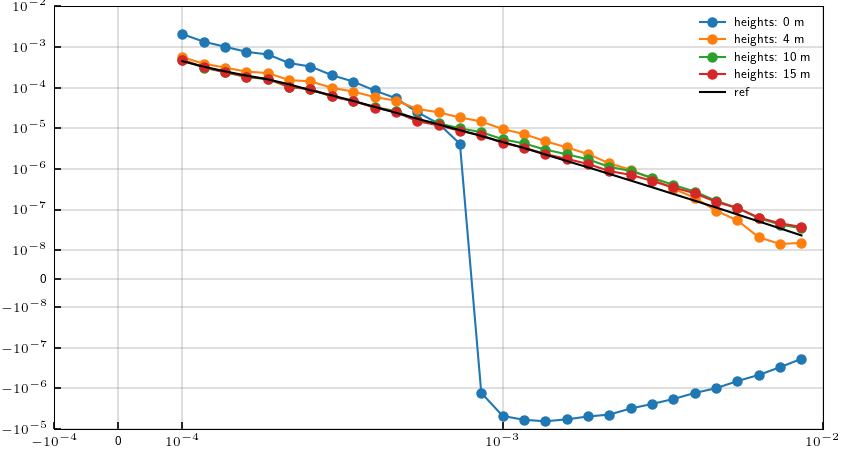

In [21]:
fig, ax= plt.subplots(1,1, figsize=(textwidth,3))


for i in range(nmodel):
   dobs = dobs_cmb[i]
   tx_height = tx_heights[i]
   label= fr'heights: {tx_height:2.0f} m'
   ax=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs, 
      label=label, color=f"C{i}", marker="o",markersize=4,ax=ax
   )
ax =PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dpred_ref, 
      label="ref", color="k", linestyle="-",ax=ax
   )
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)

ax.legend()


# Invert with Debye Decomposition model

In [22]:
taus_strt_log = -3.75*np.ones(nmodel) # np.r_[-3.25, -3.25, -3.25]
# taus_strt_log = np.r_[-4.0, -4.0, -4.0]
# taus_end_log  = np.r_[-2.00, -1.75, -1.50]
taus_end_log  = -1.50*np.ones(nmodel) #np.r_[-2.25, -2.25, -2.25]
taus_end = 10**taus_end_log
taus_strt = 10**taus_strt_log
taus_step_log = 0.25

taus_max, taus_min = taus_end_log.max(), taus_strt_log.min()
taus_colors = []
taus_cmb = []
ntau_cmb= []
for i in range(nmodel):
    ntau =  int((taus_end_log[i] - taus_strt_log[i])/taus_step_log) +1
    taus= np.logspace(taus_strt_log[i], taus_end_log[i], ntau, endpoint=True)
    taus_color = (np.linspace(taus_strt_log[i], taus_end_log[i], ntau)-taus_min)/ (taus_max-taus_min)
    
    print(taus) 
    print(taus_color)
    taus_cmb.append(taus)
    ntau_cmb.append(ntau)
    taus_colors.append(taus_color)

[0.00017783 0.00031623 0.00056234 0.001      0.00177828 0.00316228
 0.00562341 0.01       0.01778279 0.03162278]
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
[0.00017783 0.00031623 0.00056234 0.001      0.00177828 0.00316228
 0.00562341 0.01       0.01778279 0.03162278]
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
[0.00017783 0.00031623 0.00056234 0.001      0.00177828 0.00316228
 0.00562341 0.01       0.01778279 0.03162278]
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
[0.00017783 0.00031623 0.00056234 0.001      0.00177828 0.00316228
 0.00562341 0.01       0.01778279 0.03162278]
[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]


In [23]:
bool_etas_cmb = []
for i in range(nmodel):
    bool_etas_cmb.append(np.full(ntau_cmb[i], True))


In [24]:

m_refs = []

sim_inv = []
Wd_refs = []
J_refs = []

for i in range(nmodel):
    empymod_model_sim = empymod_model_sims[i]
    tx_height = tx_heights[i]
    sim=empymod_IP_simulation(ip_model='DDR',chgmin=0,
        model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
        taus=taus, times=times_sim, smp_freq=smp_freq
    )
    bool_etas = bool_etas_cmb[i]

    sim.deepsea_three_layers_bottom_fixed(
        bool_etas=bool_etas,
        res_sea=res_sea, res_base=res_base, eta_sea=eta_sea, eta_base=eta_base  
        )
    
    m_ref = np.r_[np.log(res_sea), np.zeros(bool_etas.sum())]
    m_refs.append(m_ref)

    dpred_step= sim.dpred(m_ref)
    sim.cut_off = smp_freq/2.0
    dpred_LPF = sim.dpred(m_ref)
    sim.filt_curr = filt_linrmp
    dpred_rmp = sim.dpred(m_ref)
    sim.window_mat=Window_mat
    dpred_window = sim.dpred(m_ref)
    sim_inv.append(sim) 
    opt = Optimization(sim=sim_inv[i], dobs=dpred_window)
    opt.get_Wd(ratio=relative_error, plateau=data_noise_floor )
    Wd_refs.append(opt.Wd)
    J_refs.append(sim.J(m_ref))
Wd_ref = Wd_refs[0]
ntau_max = max(ntau_cmb)

In [25]:
taus_colors

[array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
        0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
 array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
        0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
 array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
        0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
 array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
        0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])]

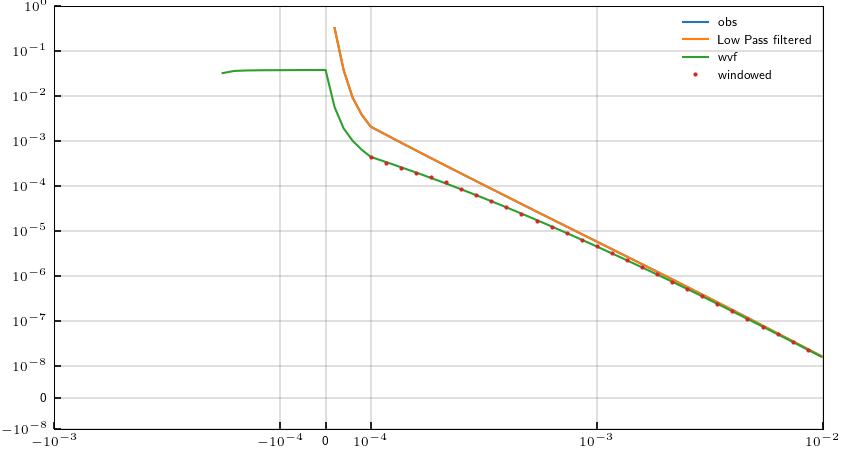

In [26]:
fig, ax= plt.subplots(1,1, figsize=(textwidth,3))

ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_step , linestyle="-",label="obs", color="C0",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_LPF , linestyle="-",label="Low Pass filtered", color="C1",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc-rmp_time,y=dpred_rmp , linestyle="-",label="wvf", color="C2",ax=ax)
ax=PL_decay.plpl_plot(
     x= windows_cen-rmp_time,y=dpred_window , marker="o",linestyle="",label="windowed", color="C3",ax=ax)
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)
#for ax in ax:
ax.legend()


In [27]:
def plot_data(data_init, dpred, dobs,ax=None):
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
       
    ax=PL_decay.semiply(windows_cen-rmp_time, data_init, ax=ax,
                       color="C1",label="ref" #
                       )
    ax=PL_decay.semiply(windows_cen-rmp_time, dpred, ax=ax
                        ,color="C0",linestyle="-",
                        label=f"est"# mated, iter={iteration}"
                        )
    ax=PL_decay.semiply(windows_cen-rmp_time, dobs, ax=ax, marker=".",markersize=2.0,
                       color="C3",linestyle="", label="obs"
                       )
    ax = PL_decay.pl_axes(ax)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EMF (V/A)")


    return ax

In [28]:
colormap = plt.get_cmap("turbo")

In [29]:
def plot_jacobian(irange, bool_etas=None,ax=None,max_y=None, min_y=None, unit=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
    taus = taus_cmb[irange]
    taus_color = taus_colors[irange]
    ntau = ntau_cmb[irange]
    if bool_etas is None:
        bool_etas = np.full(ntau, True)
    J_ref = J_refs[irange]
    Wd_ref = Wd_refs[irange]
    rho0 = Wd_ref@J_ref[:,0]
    con8 = -rho0
    sign_ip= -1
    ind_con = np.argmax(con8)
    ind_max = rho0.shape[0]-1
    windows_maxrho0 = windows_cen[np.argmax(np.abs(rho0))]
    for j in range(ntau):
        color = colormap(taus_color[j])
        label = rf"$\Delta\eta_{{{j+1}}}, \tau_{{{j+1}}}: {sci_latex(taus[j], prec=1)} s$"
        y = Wd_ref @ J_ref[:, j + nlayer]
        ind_eta = np.argmax(sign_ip*y)
        if bool_etas[j]: # only plot the jacobian for the parameters that are being inverted
            linewidth = 1
            linestyle ='-'
            marker = ""
            markersize = 2
            alpha = 1.0
            if ind_eta > ind_con and ind_eta< ind_max:
                ax = PL_jac.semiply(
                    x=windows_cen[ind_eta] - rmp_time,
                    y=y[ind_eta],
                    color=color,
                    linestyle="",
                    marker="o",
                    markersize=markersize,
                    ax=ax
                )

        else:
            linewidth = 0.5
            linestyle ='-.'
            marker = ""
            markersize = 2
            alpha = 0.5

        if unit:
            y/= np.linalg.norm(y)

        ax = PL_jac.semiply(
            x=windows_cen - rmp_time,
            y=y,
            color=color,
            linestyle=linestyle,
            label=label,
            linewidth=linewidth,
            marker=marker,
            markersize=markersize,
            alpha=alpha,
            ax=ax
        )

    ax=PL_jac.semiply(
        windows_cen-rmp_time,rho0,color="k",label=r"+$\Delta\log\rho_0$",ax=ax,
            linestyle="--", linewidth=1#, marker="o",markersize=4
            )

    ax=PL_jac.semiply(
        windows_cen-rmp_time, -rho0,color="k",label=r"-$\Delta\log\rho_0$",ax=ax,
            linestyle="-.", linewidth=1#, marker="o",markersize=4
            )
    ax = PL_jac.semiply(
        x=windows_cen[ind_con] - rmp_time, y=rho0[ind_con], color="k",
        linestyle="", marker="o", markersize=2.0, ax=ax
    )
    # ax.axvline(x=windows_maxrho0-rmp_time,  color="k", linestyle=":", label=r"peak of $-\Delta\log\rho_0$")
    ax= PL_jac.pl_axes(ax, max_y=max_y, min_y=min_y)
    ax.set_xlabel("Time (s)")
    tx_height = tx_heights[irange]
    ax.set_title(fr"$W_dJ$ for Height: {tx_height:2.0f} m")
    return ax

In [30]:
def plot_taus(irange,bool_etas=None,ax=None):
    if ax is None:
        fig , ax = plt.subplots(1,1, figsize=(5,3))

    taus = taus_cmb[irange]
    taus_color = taus_colors[irange]
    ntau = ntau_cmb[irange]
    if bool_etas is None:
        bool_etas = np.full(ntau, True)
    ax.semilogx(taus, irange*np.ones_like(taus), color="k")
    marker= 'o'
    markersize = 2.0
    for j in range(ntau):
        if bool_etas[j]: # only plot the taus for the parameters that are being inverted
            color = colormap(taus_color[j])
            ax.semilogx(taus[j], irange, 
                linestyle="", color=color, marker=marker, markersize=markersize)
    ax.set_yticks(np.arange(0, nmodel))
    ax.set_ylim(bottom=nmodel-0.5, top=-0.5)
    labels = []
    for i in range(nmodel):
        label = f"height:{tx_heights[i]:2.0f} m"
        labels.append(label)
    ax.set_yticklabels(labels=labels)

    ax.set_title(r"$\tau_k$ for each model")
    ax.set_xlabel(r"$\tau_k$ (s)")
    return ax

In [31]:
def activate_etas(WdJ, ntau=None, threshold_ratio=1e-6):
    print(ntau)
    if ntau  is not None:
        assert WdJ.shape[1] == ntau +1, "The number of columns in WdJ should be equal to ntau + 1 (for rho0)"
    else:
        ntau = WdJ.shape[1] -1
    rho0 = WdJ[:,0]
    con8 = -WdJ[:,0]
    ind = np.argmax(np.abs(con8))
    sign_ip = -np.sign(con8[ind])
    print(f"sign of con8 at the peak: {sign_ip}, index: {ind}")
    threshold = threshold_ratio * np.max(np.abs(rho0))
    boole_etas = np.full(ntau, False)
    # eta_max = 0
    ind_max = con8.shape[0]-1
    for k in range(ntau):
        etak = WdJ[:, k+1]
        ind_eta = np.argmax(sign_ip*etak)
        # print(f"k={k}, ind_etak: {ind_eta}, ind_rho0: {ind}")
        if ind_eta > ind and ind_eta< ind_max:
            print(ind_eta, ind_max)
            if np.any ((etak[ind:]+con8[ind:]) *sign_ip > threshold):
                # eta_max_tmp = etak[-1] *sign_ip
                # if eta_max_tmp >= eta_max - threshold:
                boole_etas[k] = True
                # eta_max = eta_max_tmp
    return boole_etas


In [32]:
bool_etas_cmb = []
for i in range(nmodel):
    bool_etas_cmb.append(activate_etas(WdJ=Wd_ref@J_refs[i], ntau=ntau_cmb[i]))


10
sign of con8 at the peak: -1.0, index: 10
14 29
18 29
21 29
22 29
23 29
25 29
26 29
28 29
10
sign of con8 at the peak: -1.0, index: 18
20 29
22 29
23 29
25 29
27 29
10
sign of con8 at the peak: -1.0, index: 21
22 29
23 29
25 29
27 29
10
sign of con8 at the peak: -1.0, index: 22
23 29
25 29
27 29


# deactivate etas regarding WdJ

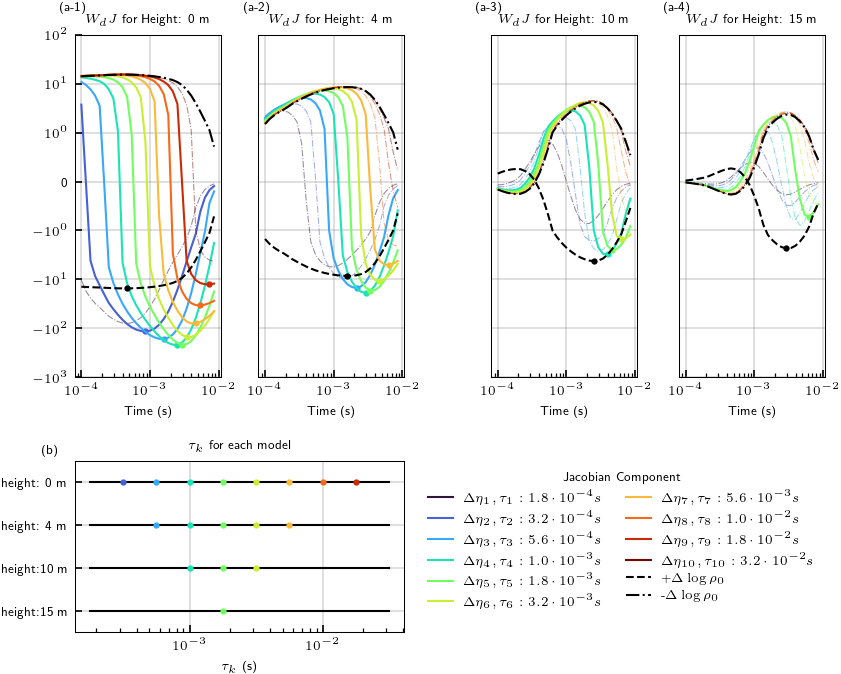

In [33]:
fig = plt.figure(figsize=(textwidth, 4.5))
gs = fig.add_gridspec(3, nmodel) 
ax_jacobians = []
for i in range(nmodel): 
    ax_jacobians.append(fig.add_subplot(gs[:2,i ], sharey=ax_jacobians[0] if i>0 else None))
ax_tau = fig.add_subplot(gs[2, :2])
ax_color = fig.add_subplot(gs[2, 2:])

ax_jacobian = ax_jacobians[0]
ax_jacobian = plot_jacobian(
    irange=0, bool_etas=np.full(ntau_cmb[0], True), ax=ax_jacobian,
    )


ax_color.axis("off")
ax_jacobian = ax_jacobians[0]

handles, labels = ax_jacobian.get_legend_handles_labels()
ax_color.legend(
    handles, labels, title="Jacobian Component",loc="upper right",
    ncol=2)

for a in ax_jacobians[1:]:
    a.tick_params(left=False, labelleft=False)
    a.set_ylabel("")

ax_jacobian.clear() # clear the dummy plot
for i in range(nmodel):
    bool_etas = bool_etas_cmb[i]
    ax_jacobian = ax_jacobians[i]
    ax_jacobian = plot_jacobian(
        irange=i, bool_etas=bool_etas, ax=ax_jacobian,
        max_y=1e2, min_y=-1e3
        )
    # ax_jacobian =  plot_jacobian_unit(irange=i, bool_etas=bool_etas, ax=ax_jacobian)
    ax_tau=plot_taus(irange=i, bool_etas=bool_etas, ax=ax_tau)


labels_axes = [
    ('(a-1)', ax_jacobians[0]),
    ('(a-2)', ax_jacobians[1]),
    ('(a-3)', ax_jacobians[2]),
    ('(a-4)', ax_jacobians[3]),
    ('(b)', ax_tau),
]

# for lab, ax in labels_axes:
#     pos = ax.get_position()
#     fig.text(
#         pos.x0 - 0.02,     # left of THIS axis
#         pos.y1 + 0.01,     # above THIS axis
#         lab,
#         fontweight='bold',
#         ha='right', va='bottom'
#     )
for label, axis in labels_axes:
    axis.text(
        -0.10, 1.10, f"{label}",   # ✅ inside axes
            transform=axis.transAxes,
    fontweight="bold",
    va="top", ha="left"
)
plt.savefig('../figures/47_DD_TEM_Jacobian.png')
plt.savefig('../manuscript/figures/47_DD_TEM_Jacobian.pdf')

In [34]:
irange = 0
J_ref = J_refs[irange]
Wd_ref = Wd_refs[irange]
WdJ = Wd_ref@J_ref
print(WdJ[:,-2])

[ 1.42455444e+01  1.43992396e+01  1.45450731e+01  1.46821756e+01
  1.48086838e+01  1.49695972e+01  1.51497514e+01  1.52813382e+01
  1.53827062e+01  1.54380714e+01  1.54244192e+01  1.53346996e+01
  1.51634144e+01  1.49061618e+01  1.45330381e+01  1.40130743e+01
  1.33366266e+01  1.23615588e+01  1.10527877e+01  9.33685493e+00
  6.96542748e+00  3.83015804e+00 -1.26156337e-02 -4.15427587e+00
 -7.75847574e+00 -1.03847643e+01 -1.19293741e+01 -1.25750873e+01
 -1.26061720e+01 -1.22218181e+01]


In [35]:
# Reset simulation
m_refs = []
sim_inv = []
taus_act_cmb = []
for i in range(nmodel):
    taus = taus_cmb[i]
    tx_height = tx_heights[i]
    empymod_model_sim = empymod_model_sims[i]
    ip_model =  "DDR" # 'DDR_MPA'
    sim=empymod_IP_simulation(ip_model=ip_model,chgmin=0,
        model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
        taus=taus, times=times_sim, smp_freq=smp_freq
    )
    bool_etas = bool_etas_cmb[i]
    sim.deepsea_three_layers_bottom_fixed(
        bool_etas=bool_etas,
        res_sea=res_sea, res_base=res_base, eta_sea=eta_sea, eta_base=eta_base  
        )
    taus_act = taus[bool_etas]
    taus_act_cmb.append(taus_act)
    m_ref = np.r_[np.log(res_sea), np.zeros(len(taus_act))]
    m_refs.append(m_ref)
    sim.cut_off = smp_freq/2.0
    sim.filt_curr = filt_linrmp
    sim.window_mat=Window_mat
    sim_inv.append(sim) 

In [36]:
taus_act_cmb

[array([0.00031623, 0.00056234, 0.001     , 0.00177828, 0.00316228,
        0.00562341, 0.01      , 0.01778279]),
 array([0.00056234, 0.001     , 0.00177828, 0.00316228, 0.00562341]),
 array([0.001     , 0.00177828, 0.00316228]),
 array([0.00177828])]

In [37]:
for i in range(nmodel):
    sim = sim_inv[i]
    print(sim.nM_m)

8
5
3
1


# Inversion: Single layer fixed thickness

In [38]:
niter = 50
stol=1e-6
coolingFactor = np.sqrt(4) #2.0
coolingRate = 2
mu=1e-3
beta0_ratio = 10
alphas= 1.0
Ws_threshold=1e-3

In [39]:
models_rec = []
dpreds = []
error_prgs = []
model_prgs = []
dinit_refs = []
data_prgs =[]
betas_prgs = []
for i in range(nmodel):
    m_ref = m_refs[i]
    sim = sim_inv[i]
    dobs= dobs_cmb[i]
    opt = Optimization(sim=sim, dobs=dobs, alphas=alphas, Ws_threshold=Ws_threshold)
    opt.get_Wd(ratio=relative_error, plateau=data_noise_floor )
    opt.get_Ws(smallness=np.ones(len(m_ref)))
    beta0 = opt.BetaEstimate_byEig(
        mvec=m_ref, update_Wsen=True, beta0_ratio=beta0_ratio)
    print(beta0)
    mpred = opt.GaussNewton(
    mvec_init=m_ref,niter=niter,beta0=beta0, update_Wsen=True,
    stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
    )
    
    dinit_refs.append(opt.dpred(m_ref))
    models_rec.append(mpred)
    dpreds.append(opt.dpred(mpred))
    error_prgs.append(opt.error_prg)
    model_prgs.append(opt.mvec_prg)
    data_prgs.append(opt.data_prg)
    betas_prgs.append(opt.betas)


528788550.1872034
  1, beta:5.3e+08, step:1.0e+00, g:1.2e+05, phid:2.4e+04, phim:5.8e-08, f:2.4e+04 
  2, beta:5.3e+08, step:1.0e+00, g:9.9e+03, phid:2.4e+04, phim:5.8e-08, f:2.4e+04 
  3, beta:2.6e+08, step:1.0e+00, g:6.0e+04, phid:2.4e+04, phim:2.3e-07, f:2.4e+04 
  4, beta:2.6e+08, step:1.0e+00, g:9.6e+03, phid:2.4e+04, phim:2.3e-07, f:2.4e+04 
  5, beta:1.3e+08, step:1.0e+00, g:6.0e+04, phid:2.3e+04, phim:9.2e-07, f:2.3e+04 
  6, beta:1.3e+08, step:1.0e+00, g:9.3e+03, phid:2.3e+04, phim:9.4e-07, f:2.3e+04 
  7, beta:6.6e+07, step:1.0e+00, g:6.0e+04, phid:2.3e+04, phim:3.6e-06, f:2.3e+04 
  8, beta:6.6e+07, step:1.0e+00, g:8.7e+03, phid:2.3e+04, phim:3.8e-06, f:2.3e+04 
  9, beta:3.3e+07, step:1.0e+00, g:6.0e+04, phid:2.2e+04, phim:1.4e-05, f:2.2e+04 
 10, beta:3.3e+07, step:1.0e+00, g:8.3e+03, phid:2.2e+04, phim:1.5e-05, f:2.2e+04 
 11, beta:1.7e+07, step:1.0e+00, g:6.1e+04, phid:2.0e+04, phim:5.5e-05, f:2.1e+04 
 12, beta:1.7e+07, step:1.0e+00, g:1.1e+04, phid:2.0e+04, phim:6.6e-0

In [40]:
phid_star=len(windows_cen)
models_rec_phid = []
dpreds_phid = []
phid_star_ratio =1.1
phid_itrs = []
chis = []
for i in range(nmodel):
    model_prg= np.array(model_prgs[i])
    data_prg = np.array(data_prgs[i])
    error_prg = error_prgs[i]
    phid_prg = np.array(error_prg)[:,1]
    ind = phid_prg < phid_star*phid_star_ratio
    if np.sum(ind) == 0:
        print(f" range {i}:No phid star found, take min phid")
        ind = phid_prg == np.min(phid_prg)
    phid = phid_prg[ind][0]
    phid_itr = np.where(ind)[0][0]
    models_rec_phid.append(model_prg[ind][0])
    dpreds_phid.append(data_prg[ind][0])
    phid_itrs.append(phid_itr)
    print(f"{phid/phid_star:.2f} of phid star at iteration {phid_itr}")
    chis.append(phid/phid_star)

 range 0:No phid star found, take min phid
1.36 of phid star at iteration 37
1.02 of phid star at iteration 19
1.06 of phid star at iteration 15
1.05 of phid star at iteration 11


In [41]:
models_rec_phid

[array([-2.17174268,  0.03338728,  0.01750975,  0.06494695,  0.05683791,
         0.08549392,  0.02465302,  0.00512633,  0.1050684 ]),
 array([-2.27016878,  0.06130726,  0.03038191,  0.05439341,  0.04200271,
         0.14371072]),
 array([-2.28441541,  0.        ,  0.09389472,  0.21519251]),
 array([-2.3495712 ,  0.30869381])]

In [42]:
print( "Parameter:  $\\rho_0$, $\\eta$, $\\tau_max$")
np_mvec_refs= []
np_mvec_ests= []
for i in range(nmodel):
    np_mvec_ref = m_refs[i]
    # mvec_est = models_rec[i]
    mvec_est = models_rec_phid[i]
    np_mvec_refs.append(np_mvec_ref)
    np_mvec_ests.append(mvec_est)
    # print(f"ref{i+1}     & {np.exp(np_mvec_ref[0]):.2e} & {np_mvec_ref[1:].sum():.3f} ")
    # print(f"est{i+1}     & {np.exp(np_mvec_est[0]):.2e} & { np_mvec_est[1:].sum():.3f} & {taus_max:.2e}")
    print(f"est_phid{i+1}& {np.exp(mvec_est[0]):.2e} & {mvec_est[1:].sum():.3f}") # & min(taus) {taus_act_cmb[i].min():.2e}")


Parameter:  $\rho_0$, $\eta$, $\tau_max$
est_phid1& 1.14e-01 & 0.393
est_phid2& 1.03e-01 & 0.332
est_phid3& 1.02e-01 & 0.309
est_phid4& 9.54e-02 & 0.309


Text(0, 0.5, 'EMF (V/A)')

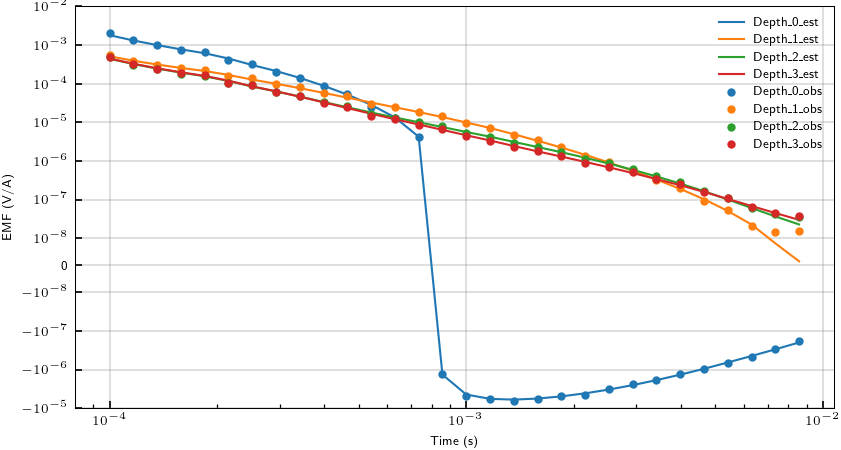

In [43]:
fig, ax= plt.subplots(1,1, figsize=(textwidth, 3))
for i in range(nmodel):
    # ax=PL_decay.semiply(
    #     windows_cen-rmp_time, dpreds[i], ax=ax,
    #     color=f"C{i}",linestyle="-", label=f"Ref/Init{i+1}"
    #     )
    ax = PL_decay.semiply(
        windows_cen-rmp_time, dpreds_phid[i], ax=ax,
        color=f"C{i}",linestyle="-", label=f"Depth_{i}_est"
        )
for i in range(nmodel):
    dobs = dobs_cmb[i]
    ax=PL_decay.semiply(
        windows_cen-rmp_time, dobs, ax=ax, marker="o",markersize=3.0,
        color=f"C{i}",linestyle="", label=f"Depth_{i}_obs"
        )
ax = PL_decay.pl_axes(ax)
ax.legend()
ax.set_xlabel("Time (s)")
ax.set_ylabel("EMF (V/A)")


# get SIP of target layer

In [44]:
def plot_each_data(data, ax=None, **kwargs):
    default_kwargs = {
        "linestyle": "-",
        "color": "C0",
        "linewidth": 1.0,
        "marker": None,
        "markersize": 1,
    }
    default_kwargs.update(kwargs)
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
       
    ax=PL_decay.semiply(windows_cen-rmp_time, data, ax=ax,
                       **default_kwargs
                       )
    ax = PL_decay.pl_axes(ax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EMF (V/A)")
    return ax

In [45]:
for i in range(nmodel):
    taus_act = taus_act_cmb[i]
    print(taus_act.shape)

(8,)
(5,)
(3,)
(1,)


In [46]:
freq_step_log  = 0.1
freq_cmb = []
freq_mins = []
freq_maxs = []
for i in range(nmodel):
    taus_act = taus_act_cmb[i]
    if taus_act.shape[0] > 0:
        taus_strt_log = np.log10(taus_act.min())
        taus_end_log = np.log10(taus_act.max())

        nfreq = int((taus_end_log - taus_strt_log)/freq_step_log) +1
        freq = np.logspace(
            -taus_end_log, -taus_strt_log, nfreq, endpoint=True
            ) 
        # freq = 10**np.arange(-taus_end_log[i], -taus_strt_log[i]+freq_step_log, freq_step_log)
        freq /= 2.0*np.pi
        freq_cmb.append(freq)
        freq_mins.append(freq.min())
        freq_maxs.append(freq.max())
        freq_min = freq.min()
    else:
        freq = np.atleast_1d(freq_min)
        freq_cmb.append(freq)
        freq_mins.append(freq)
        freq_maxs.append(freq)
    print(f"Range {i}: nfreq {nfreq}, freq min {freq.min():.2e}, max {freq.max():.2e}")


Range 0: nfreq 18, freq min 8.95e+00, max 5.03e+02
Range 1: nfreq 11, freq min 2.83e+01, max 2.83e+02
Range 2: nfreq 6, freq min 5.03e+01, max 1.59e+02
Range 3: nfreq 1, freq min 8.95e+01, max 8.95e+01


In [47]:
print(freq_cmb)
for i in range(nmodel):
    freq= freq_cmb[i]
    len(freq)

[array([  8.94994016,  11.34387176,  14.3781326 ,  18.22399808,
        23.09855635,  29.27696233,  37.10796946,  47.03361577,
        59.61417572,  75.55978611,  95.77053121, 121.38725004,
       153.85593339, 195.00934597, 247.17048072, 313.28368511,
       397.08086125, 503.29212104]), array([ 28.30219583,  35.63035354,  44.8559575 ,  56.47030477,
        71.09190169,  89.49940161, 112.67307103, 141.84699234,
       178.57478324, 224.81233253, 283.02195831]), array([ 50.3292121 ,  63.36072407,  79.76642565, 100.41998025,
       126.42126499, 159.15494309]), array([89.49940161])]


In [48]:
freq_ext_strt_log=  np.log10(min(freq_mins)) #np.log10(5) 
freq_ext_end_log = 3.0 # np.log10(max(freq_maxs)) # 3

freq_ext = np.logspace(
    start=freq_ext_strt_log,
    stop=freq_ext_end_log,
    num= int((freq_ext_end_log-freq_ext_strt_log)/freq_step_log)+1,
    endpoint=True
    )



In [49]:
noise_floor_ratio = 1e-6
relative_error_sip = 0.02
niter = 100
stol=1e-6
coolingFactor = 2 # np.sqrt(2) 
coolingRate = 2
mu=1e-3
beta0_ratio = 1.0

In [50]:
sip_trues =[]
sim_sip_dd = []
sim_sip_dd_ext = []
sim_sip_pel = []
sim_sip_pel_ext = []
sip_dpreds = []
model_recs_sip = []
dpreds_sip = []
error_prgs_sip = []
model_prgs_sip = []
dinit_refs_sip = []
data_prgs_sip =[]
betas_prgs_sip = []
tem_inv_taus = []

for i in range(nmodel):
    freq = freq_cmb[i]
    nfreq = len(freq)
    mvec_obs= m_trues[i]
    mvec_est = models_rec_phid[i]
    IP_model = Pelton_res_f(freq=freq)
    sim = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_pel.append(sim)
    dobs_sip = sim.dpred(m=mvec_obs)
    sip_trues.append(dobs_sip)
    f_abs = abs(IP_model.f(mvec_obs))

    IP_model = Pelton_res_f(freq=freq_ext)
    sim_sip = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_pel_ext.append(sim_sip)

    taus_act = taus_act_cmb[i]

    IP_model = DDR_f(freq=freq_ext,taus=taus_act)
    sim = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_dd_ext.append(sim)

    IP_model = DDR_f(freq=freq,taus=taus_act)
    sim = InducedPolarizationSimulation(ip_model=IP_model, mode='sip')
    sim_sip_dd.append(sim)

    sip_dpreds.append(sim.dpred(mvec_est))
    tau_mean = IP_model.mean_log_tau(mvec_est)
    tem_inv_taus.append(tau_mean)

    if nfreq >= 1:
        noise_floor= f_abs.max()*noise_floor_ratio
        mvec_ref = m_refs[i]
        opt = Optimization(sim=sim, dobs= dobs_sip)
        opt.get_Wd(ratio=relative_error_sip, plateau=noise_floor)
        opt.get_Ws(np.ones(len(mvec_ref)))
        beta0 = opt.BetaEstimate_byEig(mvec=mvec_ref, update_Wsen=True)
        mpred = opt.GaussNewton(
            mvec_init=mvec_ref,niter=niter,beta0=beta0, update_Wsen=True,
            stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
            )
        dinit_refs_sip.append(opt.dpred(mvec_ref))
        error_prgs_sip.append(opt.error_prg)
        model_prgs_sip.append(opt.mvec_prg)
        data_prgs_sip.append(opt.data_prg)
        betas_prgs_sip.append(opt.betas)
        model_recs_sip.append(mpred)
        dpreds_sip.append(opt.dpred(mpred))
    else:
        mpred = np.log(f_abs)
        model_recs_sip.append(mpred)
        dpreds_sip.append(np.r_[f_abs,0])
        


  1, beta:2.4e+08, step:1.0e+00, g:1.9e+06, phid:3.5e+05, phim:4.5e-05, f:3.6e+05 
  2, beta:2.4e+08, step:2.5e-01, g:2.5e+04, phid:3.5e+05, phim:4.4e-05, f:3.6e+05 
  3, beta:1.2e+08, step:1.0e+00, g:8.1e+05, phid:3.2e+05, phim:1.4e-04, f:3.4e+05 
  4, beta:1.2e+08, step:1.2e-01, g:2.1e+04, phid:3.2e+05, phim:1.4e-04, f:3.4e+05 
  5, beta:5.9e+07, step:1.0e+00, g:7.2e+05, phid:2.8e+05, phim:4.2e-04, f:3.0e+05 
  6, beta:5.9e+07, step:1.2e-01, g:2.9e+04, phid:2.8e+05, phim:4.2e-04, f:3.0e+05 
  7, beta:3.0e+07, step:1.0e+00, g:5.8e+05, phid:2.2e+05, phim:1.1e-03, f:2.6e+05 
  8, beta:3.0e+07, step:6.2e-02, g:3.3e+04, phid:2.2e+05, phim:1.1e-03, f:2.6e+05 
  9, beta:1.5e+07, step:1.0e+00, g:4.2e+05, phid:1.7e+05, phim:2.5e-03, f:2.1e+05 
 10, beta:1.5e+07, step:7.8e-03, g:3.3e+04, phid:1.7e+05, phim:2.5e-03, f:2.1e+05 
 11, beta:7.4e+06, step:1.0e+00, g:2.8e+05, phid:1.2e+05, phim:5.2e-03, f:1.6e+05 
 12, beta:7.4e+06, step:9.5e-07, g:2.8e+04, phid:1.2e+05, phim:5.3e-03, f:1.6e+05 
 13,

 29, beta:1.4e+04, step:1.0e+00, g:2.5e+03, phid:8.0e+01, phim:8.7e-02, f:1.3e+03 
 30, beta:1.4e+04, step:9.5e-07, g:1.4e+02, phid:8.0e+01, phim:8.9e-02, f:1.4e+03 
 31, beta:7.2e+03, step:1.0e+00, g:1.3e+03, phid:2.3e+01, phim:9.2e-02, f:6.9e+02 
 32, beta:7.2e+03, step:9.5e-07, g:4.6e+01, phid:2.3e+01, phim:9.3e-02, f:6.9e+02 
 33, beta:3.6e+03, step:1.0e+00, g:6.7e+02, phid:6.6e+00, phim:9.4e-02, f:3.5e+02 
 34, beta:3.6e+03, step:9.5e-07, g:1.3e+01, phid:6.6e+00, phim:9.5e-02, f:3.5e+02 
 35, beta:1.8e+03, step:1.0e+00, g:3.4e+02, phid:2.0e+00, phim:9.6e-02, f:1.7e+02 
 36, beta:1.8e+03, step:9.5e-07, g:3.6e+00, phid:2.0e+00, phim:9.6e-02, f:1.8e+02 
 37, beta:9.0e+02, step:1.0e+00, g:1.7e+02, phid:7.0e-01, phim:9.6e-02, f:8.8e+01 
 38, beta:9.0e+02, step:9.5e-07, g:9.5e-01, phid:7.0e-01, phim:9.7e-02, f:8.8e+01 
 39, beta:4.5e+02, step:1.0e+00, g:8.7e+01, phid:3.4e-01, phim:9.7e-02, f:4.4e+01 
 40, beta:4.5e+02, step:9.5e-07, g:2.4e-01, phid:3.4e-01, phim:9.7e-02, f:4.4e+01 
 41,

In [51]:
phid_star_ratio = 1.0

sip_true_inv = []
sip_true_dpred = []
sip_true_inv_taus = []
dpreds_sip_inv = []
for i in range(nmodel):
    sim = sim_sip_dd[i]
    sim_tem = sim_inv[i]
    freq = freq_cmb[i]
    taus = taus_act_cmb[i]
    nfreq = freq.shape[0]
    if nfreq >= 1:
        phid_star = nfreq*2
        model_prg= np.array(model_prgs_sip[i])
        data_prg = np.array(data_prgs_sip[i])
        error_prg = error_prgs_sip[i]
        phid_prg = np.array(error_prg)[:,1]
        ind = phid_prg < phid_star*phid_star_ratio
        if np.sum(ind) == 0:
            ind = phid_prg == np.min(phid_prg)
            print(f" range {i}:No phid star found, take min phid")
        model = model_prg[ind][0]
        sip_true_inv.append(model)

        tau_mean = sim.ip_model.mean_log_tau(model)
        sip_true_inv_taus.append(tau_mean)

        sip_true_dpred.append(data_prg[ind][0])
        rho0_sip = np.exp(model[0])
        eta_sip = model[1:].sum()
    else:
        model = model_recs_sip[i]
        sip_true_inv.append(model)
        sip_true_inv_taus.append(np.nan)
        sip_true_dpred.append(dpreds_sip[i])
        rho0_sip = np.exp(model[0])
        eta_sip = model[1:].sum()
    dpreds_sip_inv.append(sim_inv[i].dpred(m=model))
    print(f"Model {i}: rho0: {rho0_sip:.2e}, eta: {eta_sip:.3f}, tau_mean: {tau_mean:.2e}")


Model 0: rho0: 1.00e-01, eta: 0.363, tau_mean: 2.14e-03
Model 1: rho0: 9.79e-02, eta: 0.339, tau_mean: 1.94e-03
Model 2: rho0: 9.50e-02, eta: 0.295, tau_mean: 1.89e-03
Model 3: rho0: 9.26e-02, eta: 0.263, tau_mean: 1.78e-03


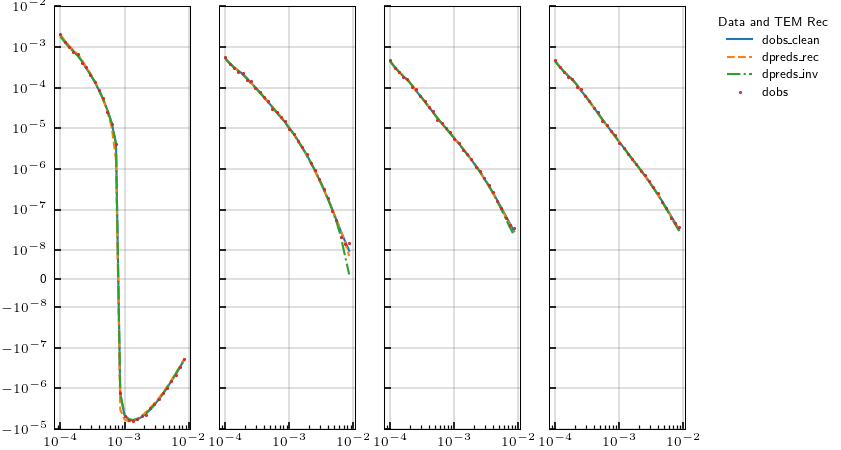

In [52]:
fig, ax= plt.subplots(1,nmodel+1,sharey=True, figsize=(textwidth,3))

ax= ax.flatten()
 # For reproducibility
for i in range(nmodel):
    sim_obs = sim_obs_cmb[i]
    dobs = dobs_cmb[i]
    mvec_obs = m_trues[i]
   # np.random.seed(i) # if you wanto have different noise for each model 
    # if you want the same noise for each model
   # Calculate noise floor and relative erro at each window
    mvec_obs = m_trues[i]
    dobs_clean=sim_obs.dpred(mvec_obs)

    ax[i]=PL_decay.semiply(x= windows_cen-rmp_time,y=dobs_clean, 
      label="dobs_clean", color="C0", linestyle="-",ax=ax[i]
    )

    ax[i]=PL_decay.semiply(x= windows_cen-rmp_time,y=dpreds_sip_inv[i], 
      label="dpreds_rec", color="C1", linestyle="--",ax=ax[i]
    )
    ax[i]=PL_decay.semiply(x= windows_cen-rmp_time,y=dpreds_phid[i], 
      label="dpreds_inv", color="C2", linestyle="-.",ax=ax[i]
    )
    ax[i]=PL_decay.semiply(x= windows_cen-rmp_time,y=dobs, 
      label="dobs", color="C3", marker=".",markersize=1,linestyle="",ax=ax[i]
    )
    ax[i]= PL_decay.pl_axes(ax[i], max_y=0.9e-2, min_y=-0.9e-5)
#for ax in ax:

    if i == 0:
        handles, labels = ax[i].get_legend_handles_labels()
        ax[-1].axis("off")
        ax[-1].legend(handles, labels, title="Data and TEM Rec", loc="upper right",ncol=1)
 
plt.savefig('../figures/47_DD_TEM_dpreds_rec.jpg')


In [53]:
# title_heads= ['model_1', 'model_2', 'model_3']
title_heads = []
column_labels = []  
for i in range(nmodel):
    title_head = f'Height_{tx_heights[i]:2.0f}m'
    title_heads.append(title_head)
    colmun_label = f"{i+1}"
    column_labels.append(colmun_label)
# title_heads = ["model_1", "model_2", "model_3"]

print(title_heads)
print(column_labels)


['Height_ 0m', 'Height_ 4m', 'Height_10m', 'Height_15m']
['1', '2', '3', '4']


In [54]:
for i in range(nmodel):
    sim= sim_sip_dd_ext[i]
    print(f"Model {i}: taus = {sim.ip_model.taus}")

Model 0: taus = [0.00031623 0.00056234 0.001      0.00177828 0.00316228 0.00562341
 0.01       0.01778279]
Model 1: taus = [0.00056234 0.001      0.00177828 0.00316228 0.00562341]
Model 2: taus = [0.001      0.00177828 0.00316228]
Model 3: taus = [0.00177828]


In [55]:
def plot_each_data(data, ax=None, **kwargs):
    default_kwargs = {
        "linestyle": "-",
        "color": "C0",
        "linewidth": 1.0,
        "marker": None,
        "markersize": 1,
    }
    default_kwargs.update(kwargs)
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
       
    ax=PL_decay.semiply(windows_cen-rmp_time, data, ax=ax,
                       **default_kwargs
                       )
    ax = PL_decay.pl_axes(ax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EMF (V/A)")
    title = (
        'Data Plot; ' +
        r'$\varepsilon_{{rel}}$: ' + f"{relative_error*100:.1f} \%, " +
        r'$\varepsilon_{{floor}}$: ' + rf"${fmt(data_noise_floor,prec=1)}$"
    )
    ax.set_title(title)
    return ax

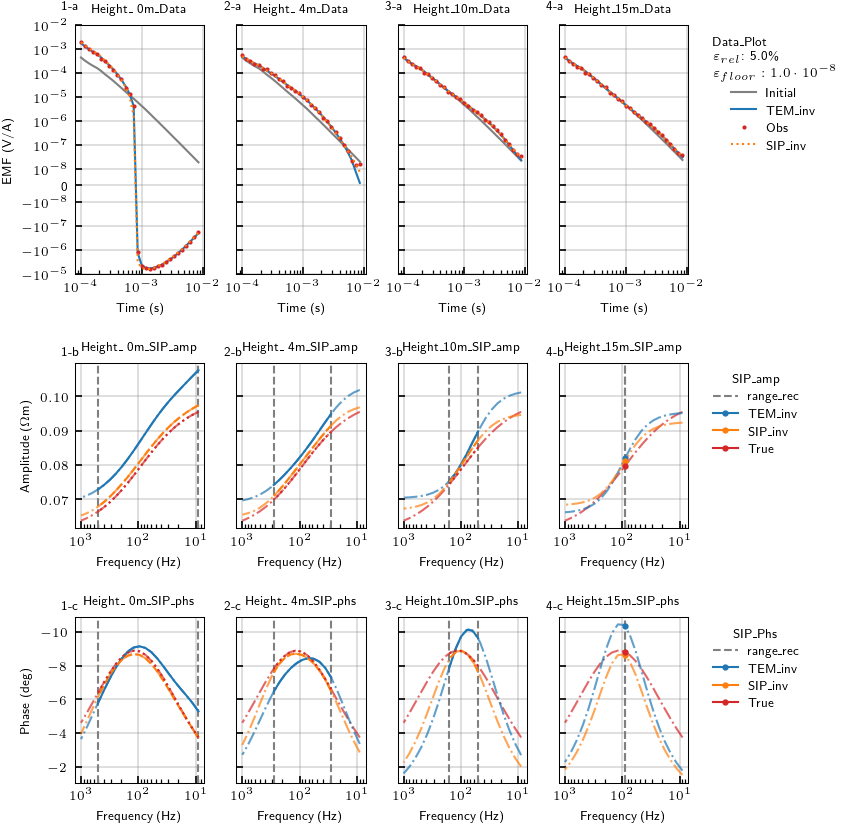

In [56]:
fig, ax = plt.subplots(3, nmodel,
        sharex='row', sharey='row', figsize=(textwidth,5.5), #  constrained_layout=True,  
    gridspec_kw={"height_ratios": [1.5, 1.0, 1.0]}  # key line
    )
ax_ranges = []
for i in range(nmodel):
    ax_ranges.append([ax[0, i], ax[1, i], ax[2, i]])

for i in range(nmodel-1, -1, -1):
    dobs= dobs_cmb[i]
    mvec_obs = m_trues[i]
    m_sip_inv= sip_true_inv[i]
    title_head= title_heads[i]
    phid_itr = phid_itrs[i]
    m_tem_inv = models_rec_phid[i]
    freq = freq_cmb[i]
    nfreq = len(freq)
    ax_range = ax_ranges[i]
    axdata = ax_range[0]
    axsip = [ax_range[1], ax_range[2]]
    axdata = plot_each_data(data=dinit_refs[i], label="Initial",color="gray",ax=axdata)
    axdata = plot_each_data(data=dpreds_phid[i], label="TEM_inv",color="C0",ax=axdata)
    axdata = plot_each_data(data=dobs,label="Obs",color="C3",
                            linestyle="", marker='.',markersize=2.0, ax=axdata)
    axdata = plot_each_data(data=dpreds_sip_inv[i], label="SIP_inv",color=f"C1",
                            linestyle=':',ax=axdata)
    for a in axsip:
        a.axvline(x=freq_mins[i], color='gray', linestyle='--', label=f"range_rec" )
        a.axvline(x=freq_maxs[i], color='gray', linestyle='--')

    sim = sim_sip_pel_ext[i]
    axsip = sim.plot_sip_model(model=mvec_obs, ax=axsip,
            color="C3", linestyle="-.", alpha=0.7)
    sim=sim_sip_dd_ext[i]
    # print(f"Model {i}: taus for ext sim: {sim.ip_model.taus}"   )
    axsip= sim.plot_sip_model(model=m_tem_inv, ax=axsip,
            color="C0", linestyle="-.", alpha=0.7 )
    axsip = sim.plot_sip_model(model=m_sip_inv, ax=axsip,
            color="C1", linestyle="-.", alpha=0.7)
     
    if freq.shape[0] == 1:
        linestyle_tem, linestyle_sip, linestyle_true= "-", "-" , "-"
        marker, markersize = "o", 2.0
    else:
        linestyle_tem, linestyle_sip, linestyle_true= "-", "--" , ":"
        marker, markersize = "", 1.0
    sim = sim_sip_dd[i]
    axsip = sim.plot_sip_model(model=m_tem_inv, ax=axsip,color="C0", label="TEM_inv", 
            linestyle=linestyle_tem, marker=marker, markersize=markersize)
    axsip = sim.plot_sip_model(model=m_sip_inv, ax=axsip, color="C1", label="SIP_inv",
            linestyle=linestyle_sip, marker=marker, markersize=markersize)
    sim = sim_sip_pel[i]
    axsip = sim.plot_sip_model(model=mvec_obs, ax=axsip, color="C3", label="True",
            linestyle=linestyle_true, marker=marker, markersize=markersize)

    if i == (nmodel-1):
        title = (
            'Data_Plot \n' +
            rf'$\varepsilon_{{rel}}$: {relative_error*100:.1f}\%' + '\n' +
            rf'$\varepsilon_{{floor}}:{fmt(data_noise_floor,prec=1)}$'
        )
        axdata.legend(title=title,loc="upper left", bbox_to_anchor=(1.1,1))
        title = 'SIP_amp'
        axsip[0].legend(title=title,loc="upper left", bbox_to_anchor=(1.1,1))
        title = 'SIP_Phs'
        axsip[1].legend(title=title,loc="upper left", bbox_to_anchor=(1.1,1))
       

    ax_range[0].set_title(f"{title_head}_Data")
    ax_range[1].set_title(f"{title_head}_SIP_amp")
    ax_range[2].set_title(f"{title_head}_SIP_phs")
    column_label = column_labels[i]
    low_names= ['-a', '-b', '-c']

    for label, axis in zip(low_names, ax_range):
        axis.text(
            -0.1, 1.1, f"{column_label}{label}",   # ✅ inside axes
             transform=axis.transAxes,
        fontweight="bold",
        va="top", ha="left"
    )
axsip[0].invert_xaxis()
axsip[1].invert_xaxis()
axsip[1].invert_yaxis()

for acol in ax[:, 1:nmodel]:
    for a in acol:
        a.tick_params(labelleft=False)
        a.set_ylabel("")

plt.savefig('../figures/47_DD_TEM_data_rec.png')
plt.savefig('../manuscript/figures/47_DD_TEM_data_rec.pdf')

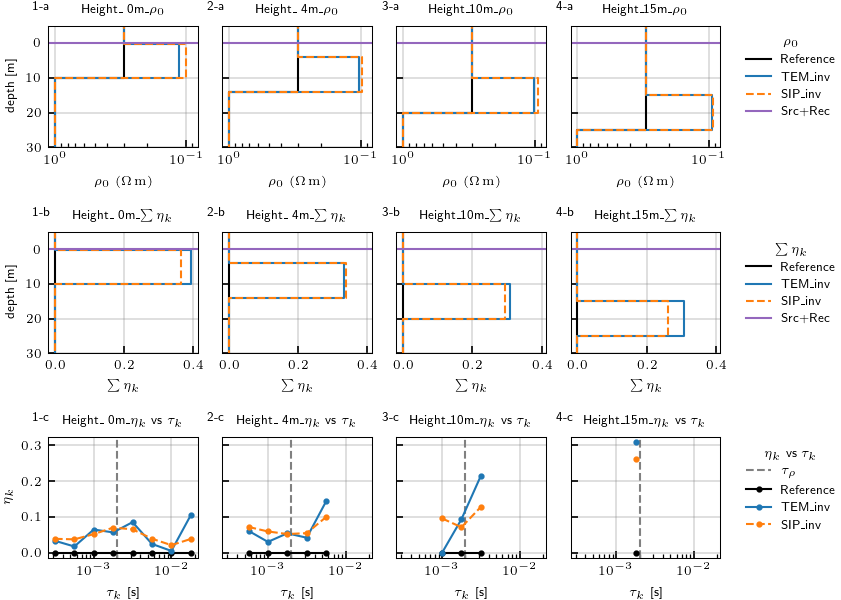

In [57]:
fig, ax = plt.subplots(
    3, nmodel, sharex='row', sharey='row',
    figsize=(textwidth ,4.0), #constrained_layout=True,  
)
ax_ranges = []
for i in range(nmodel):
    ax_ranges.append([ax[0, i], ax[1, i], ax[2, i]])

for i in range(nmodel):
    title_head = title_heads[i]
    ax_range = ax_ranges[i]
    axrm = ax_range[0:2]
    axetas = ax_range[2]
    m_ref = m_refs[i]
    taus = taus_act_cmb[i]
    tau_target = tau_targets[i]
    sim = sim_inv[i]
    linewidth = 1.0
    axrm = sim.plot_IP_par(mvec=m_ref, rm=True,
        label="Reference", color="k", linestyle="-",
        ax=axrm, linewidth=linewidth)
    axrm = sim.plot_IP_par(mvec=models_rec_phid[i], rm=True,
        label="TEM_inv", color="C0", linestyle="-", 
        ax=axrm, linewidth=linewidth)
    # rho0,eta = sim.ip_model.get_rho_eta(models_rec_phid[i])
    # label = fr"Est $\rho_0$:{rho0: .1e},$\eta$:{eta: .2f}"
    axrm = sim.plot_IP_par(mvec=sip_true_inv[i], rm=True,
            label="SIP_inv", color=f"C1", linestyle="--",
            ax=axrm, linewidth=linewidth)
    # rho0,eta = sim.ip_model.get_rho_eta(sip_true_inv[i])
    # label = fr"Rec $\rho_0$:{rho0: .1e},$\eta$:{eta: .2f}"
    sim= sim_sip_dd[i]
    label = fr"$\tau_\rho$" 
    axetas.axvline(x=tau_target, color='gray', linestyle='--', 
                     label=label)
    marker, markersize = "o", 2.0
    axetas = sim.ip_model.plot_etas(m_ref, ax=axetas, color="k",
             label="Reference", linestyle="-", 
             marker=marker, markersize=markersize, linewidth=linewidth
             )
    axetas = sim.ip_model.plot_etas(models_rec_phid[i],
             ax=axetas, color="C0",
             label="TEM_inv", linestyle="-", 
             marker=marker, markersize=markersize
             )
    axetas = sim.ip_model.plot_etas(sip_true_inv[i],
             ax=axetas, color="C1", label="SIP_inv",
             linestyle="--", linewidth=linewidth,
             marker=marker, markersize=markersize)

    axrm[0].set_title(fr"{title_head}_$\rho_0$")
    axrm[1].set_title(fr"{title_head}_$\sum\eta_k$")
    axetas.set_title(fr"{title_head}_$\eta_k$ vs $\tau_k$")
    # label = r"TEM_$\bar{\tau}$" 
    # axetas.axvline(x=tem_inv_taus[i], color='C0', linestyle='-', linewidth=linewidth_vline,
    #                  label=label)
    # label = r"SIP_$\bar{\tau}$" 
    # axetas.axvline(x=sip_true_inv_taus[i], color='C3', linestyle='--', linewidth=linewidth_vline,
    #                  label=label)
    for j , a in enumerate(axrm):  # Iterate over rows
        a.axhline(empymod_model_sim["src"][4], color=f"C4", linestyle="-", label="Src+Rec")
        # a.set_ylim([12.5, -2.5])
        a.set_ylim([30, -5.0])
        a.set_ylabel('depth [m]')
        if j== 0:
            a.set_xscale("log")
        else:
            a.set_xscale("linear")
    if i == nmodel-1:
        title=r"$\rho_0$"
        axrm[0].legend(title=title, loc="upper left", bbox_to_anchor=(1.1,1))
        title = r"$\sum\eta_k$"
        axrm[1].legend(title=title, loc="upper left", bbox_to_anchor=(1.1,1))
        title = r"$\eta_k$ vs $\tau_k$"
        axetas.legend(title=title, loc="upper left", bbox_to_anchor=(1.1,1))


    column_label = column_labels[i]
    for label, axis in zip(low_names, ax_range):
        axis.text(
            -0.1, 1.2, f"{column_label}{label}",   # ✅ inside axes
             transform=axis.transAxes,
        fontweight="bold",
        va="top", ha="left"
    )

axrm[0].invert_xaxis()

for acol in ax[:, 1:nmodel]:
    for a in acol:
        a.tick_params(labelleft=False)
        a.set_ylabel("")

plt.savefig('../figures/47_Recovered_DD.png')
plt.savefig('../manuscript/figures/47_Recovered_DD.pdf')

In [58]:
ntau_print=[]
sip_inv_print=[]
tem_inv_print=[]
phid_print=[]
taurange_print = []
freqrange_print = []
for i in range(nmodel):
    taus_strt = taus_act_cmb[i].min() if taus_act_cmb[i].shape[0] > 0 else None
    taus_end = taus_act_cmb[i].max() if taus_act_cmb[i].shape[0] > 0 else None

    sip_inv_print.append(sip_true_inv[i])
    tem_inv_print.append(models_rec_phid[i])
    
    ntau_print.append(taus_act_cmb[i].shape[0])
    if taus_strt == taus_end:
        taurange_print.append(np.r_[taus_strt])
        freqrange_print.append(np.r_[freq_mins[i]])
    else:
        taurange_print.append(np.r_[taus_strt, taus_end])
        freqrange_print.append(np.r_[freq_mins[i], freq_maxs[i]])


In [59]:
taurange_print

[array([0.00031623, 0.01778279]),
 array([0.00056234, 0.00562341]),
 array([0.001     , 0.00316228]),
 array([0.00177828])]

In [60]:
rho0_print =[]
eta_print =[]
tau_print = []
c_print = []

ind = 0
rho0_print.append(rho0_targets[ind])
eta_print.append(eta_targets[ind])
tau_print.append(tau_targets[ind])
c_print.append(c_targets[ind])

for i in range(nmodel):

    model = np.array(tem_inv_print[i])
    rho0 = np.exp(model[0])
    eta = model[1:].sum()
    rho0_print.append(rho0)
    eta_print.append(eta)
    tau_print.append(tem_inv_taus[i])
    # tau_print.append("")
    c_print.append("")
    
    model = np.array(sip_inv_print[i])
    rho0 = np.exp(model[0])
    eta = model[1:].sum() 
    rho0_print.append(rho0)
    eta_print.append(eta)
    tau_print.append(sip_true_inv_taus[i])
    # tau_print.append("")
    c_print.append("")

names_print=[]
names_print.append(f"True")
for i in range(nmodel):
    names_print.append(f"TEM inv")
    names_print.append(f"SIP inv")

titles_print=[]
for i in range(nmodel):
    titles_print.append(f"Height {tx_heights[i]:2.0f} m")

In [61]:

print(r" \multicolumn{2}{c|}{Height (\si{\meter})}  & \multicolumn{2}{c|}{"
      + r"} & \multicolumn{2}{c|}{".join(f"{v}" for v in titles_print
                                         )
       + r"} \\"
)
print("\hline")
print(r"\multicolumn{2}{c|}{$\tau_k$ band (\si{\second})} & \multicolumn{2}{c|}{\num{"
      + r"}} & \multicolumn{2}{c|}{\num{".join(
          r"} to \num{".join(f"{v:.1e}" for v in z)
          for z in taurange_print)
       + r"}} \\"
)
print("\hline")
print(r"\multicolumn{2}{c|}{n} & \multicolumn{2}{c|}{\num{"
      +r"}} & \multicolumn{2}{c|}{\num{".join(f"{v:2.0f}" for v in ntau_print)
       + r"}} \\"
)
print("\hline")
print(r"  \multicolumn{2}{c|}{Frequency band (\si{\hertz})}& \multicolumn{2}{c|}{\num{"
      + r"}} & \multicolumn{2}{c|}{\num{".join(
          r"} to \num{".join(f"{v:.1e}" for v in z)
          for z in freqrange_print)
       + r"}} \\")
print("\hline")
print(" & "
      +" & ".join(f"{v}" for v in names_print)
       + r"\\"
)
print(r"$\rho_0$ (\si{\Omega \meter})& \num{"
      +r"} & \num{".join(f"{v:4.2f}" for v in  rho0_print)
       + r"} \\"
)
print(r"$\sum\eta_k$ & \num{"
      +r"} & \num{".join(f"{v:4.2f}" for v in eta_print)
     + r"} \\"
)
# print(r"$\tau$ & \num{"
#       +r"} & \num{".join(f"{v:.1e}" for v in tau_print)
#      + r"} \\"
# )
# print(r"$C$ & \num{0.7}"
#     + " &"*8 + r'\\'
# )

 \multicolumn{2}{c|}{Height (\si{\meter})}  & \multicolumn{2}{c|}{Height  0 m} & \multicolumn{2}{c|}{Height  4 m} & \multicolumn{2}{c|}{Height 10 m} & \multicolumn{2}{c|}{Height 15 m} \\
\hline
\multicolumn{2}{c|}{$\tau_k$ band (\si{\second})} & \multicolumn{2}{c|}{\num{3.2e-04} to \num{1.8e-02}} & \multicolumn{2}{c|}{\num{5.6e-04} to \num{5.6e-03}} & \multicolumn{2}{c|}{\num{1.0e-03} to \num{3.2e-03}} & \multicolumn{2}{c|}{\num{1.8e-03}} \\
\hline
\multicolumn{2}{c|}{n} & \multicolumn{2}{c|}{\num{ 8}} & \multicolumn{2}{c|}{\num{ 5}} & \multicolumn{2}{c|}{\num{ 3}} & \multicolumn{2}{c|}{\num{ 1}} \\
\hline
  \multicolumn{2}{c|}{Frequency band (\si{\hertz})}& \multicolumn{2}{c|}{\num{8.9e+00} to \num{5.0e+02}} & \multicolumn{2}{c|}{\num{2.8e+01} to \num{2.8e+02}} & \multicolumn{2}{c|}{\num{5.0e+01} to \num{1.6e+02}} & \multicolumn{2}{c|}{\num{8.9e+01}} \\
\hline
 & True & TEM inv & SIP inv & TEM inv & SIP inv & TEM inv & SIP inv & TEM inv & SIP inv\\
$\rho_0$ (\si{\Omega \meter})& \num{